<a href="https://colab.research.google.com/github/aakankshalahane/SQL-Projects-/blob/main/Hospital_Patient_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,patient_id,patient_name,age,gender,city,disease,doctor,admission_date,discharge_date,bill_amount,insurance,treatment_status
0,1,Aarav,25,Male,Mumbai,Diabetes,Dr Sharma,2026-01-02,2026-01-06,45000,Yes,Recovered
1,2,Priya,42,Female,Pune,Heart Disease,Dr Mehta,2026-01-05,2026-01-14,125000,Yes,Recovered
2,3,Rahul,35,Male,Delhi,Asthma,Dr Singh,2026-01-08,2026-01-11,35000,No,Recovered
3,4,Sneha,58,Female,Mumbai,Heart Disease,Dr Mehta,2026-01-10,2026-01-22,185000,Yes,Recovered
4,5,Amit,31,Male,Bangalore,Fracture,Dr Rao,2026-01-12,2026-01-18,65000,No,Recovered
5,6,Neha,47,Female,Pune,Diabetes,Dr Sharma,2026-01-15,2026-01-20,52000,Yes,Recovered
6,7,Rohan,65,Male,Delhi,Heart Disease,Dr Mehta,2026-01-18,2026-02-02,210000,Yes,Critical
7,8,Isha,29,Female,Mumbai,Migraine,Dr Patel,2026-01-20,2026-01-22,18000,No,Recovered
8,9,Karan,51,Male,Hyderabad,Diabetes,Dr Sharma,2026-01-23,2026-01-30,72000,Yes,Recovered
9,10,Meera,38,Female,Bangalore,Asthma,Dr Singh,2026-01-25,2026-01-29,31000,No,Recovered


Disease Analysis


,disease,patient_count,average_age,average_bill
0,Heart Disease,5,59.6,191000.0
1,Diabetes,4,39.0,54500.0
2,Migraine,2,27.5,17000.0
3,Fracture,2,37.5,61500.0
4,Asthma,2,36.5,33000.0


Doctor Analysis


,doctor,patients_treated,total_revenue,average_bill
0,Dr Mehta,5,955000,191000.0
1,Dr Sharma,4,218000,54500.0
2,Dr Rao,2,123000,61500.0
3,Dr Singh,2,66000,33000.0
4,Dr Patel,2,34000,17000.0


...

,age_group,patient_count,average_bill
0,65+,2,225000.00
1,50-64,3,150666.67
2,30-49,7,59285.71
3,Under 30,3,26333.33


Doctor Revenue Ranking


,doctor,total_revenue,revenue_rank
0,Dr Mehta,955000,1
1,Dr Sharma,218000,2
2,Dr Rao,123000,3
3,Dr Singh,66000,4
4,Dr Patel,34000,5


Revenue by Disease


,disease,total_revenue
0,Heart Disease,955000
1,Diabetes,218000
2,Fracture,123000
3,Asthma,66000
4,Migraine,34000


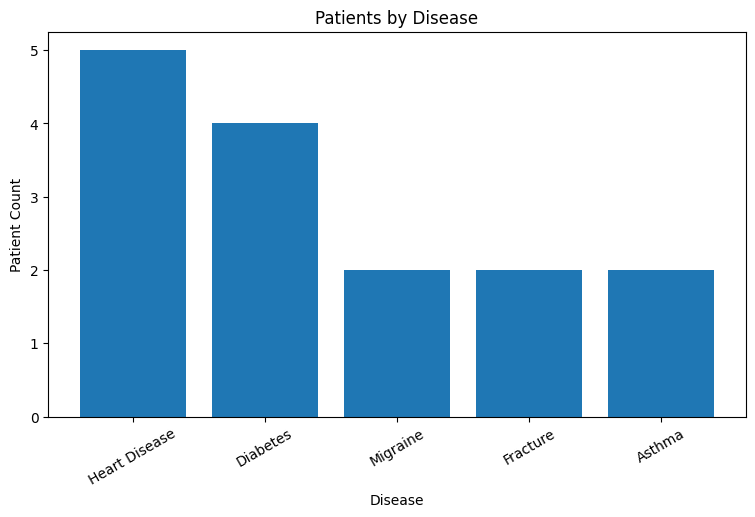

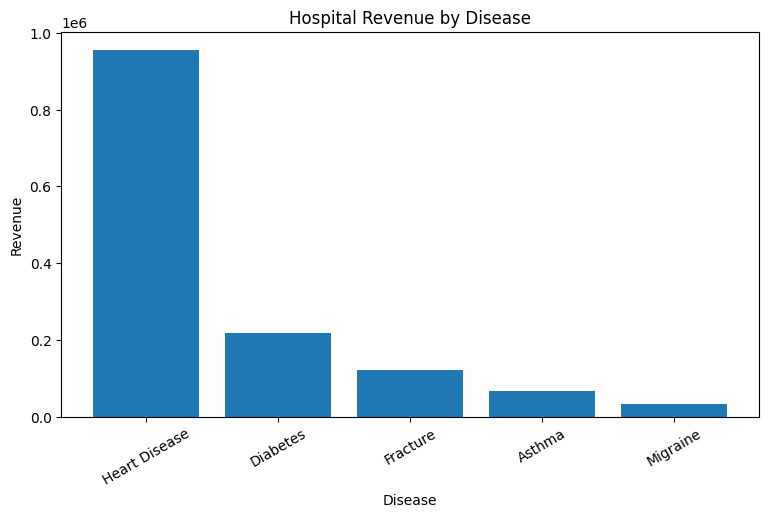

Database connection closed successfully


In [ ]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Create database
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Create patients table
cursor.execute("""
CREATE TABLE patients (
    patient_id INT,
    patient_name VARCHAR(50),
    age INT,
    gender VARCHAR(20),
    city VARCHAR(50),
    disease VARCHAR(50),
    doctor VARCHAR(50),
    admission_date DATE,
    discharge_date DATE,
    bill_amount DECIMAL(10,2),
    insurance VARCHAR(20),
    treatment_status VARCHAR(30)
)
""")

# Insert patient dataset
cursor.executemany("""
INSERT INTO patients VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
""", [
    (1,'Aarav',25,'Male','Mumbai','Diabetes','Dr Sharma','2026-01-02','2026-01-06',45000,'Yes','Recovered'),
    (2,'Priya',42,'Female','Pune','Heart Disease','Dr Mehta','2026-01-05','2026-01-14',125000,'Yes','Recovered'),
    (3,'Rahul',35,'Male','Delhi','Asthma','Dr Singh','2026-01-08','2026-01-11',35000,'No','Recovered'),
    (4,'Sneha',58,'Female','Mumbai','Heart Disease','Dr Mehta','2026-01-10','2026-01-22',185000,'Yes','Recovered'),
    (5,'Amit',31,'Male','Bangalore','Fracture','Dr Rao','2026-01-12','2026-01-18',65000,'No','Recovered'),
    (6,'Neha',47,'Female','Pune','Diabetes','Dr Sharma','2026-01-15','2026-01-20',52000,'Yes','Recovered'),
    (7,'Rohan',65,'Male','Delhi','Heart Disease','Dr Mehta','2026-01-18','2026-02-02',210000,'Yes','Critical'),
    (8,'Isha',29,'Female','Mumbai','Migraine','Dr Patel','2026-01-20','2026-01-22',18000,'No','Recovered'),
    (9,'Karan',51,'Male','Hyderabad','Diabetes','Dr Sharma','2026-01-23','2026-01-30',72000,'Yes','Recovered'),
    (10,'Meera',38,'Female','Bangalore','Asthma','Dr Singh','2026-01-25','2026-01-29',31000,'No','Recovered'),
    (11,'Vikram',72,'Male','Pune','Heart Disease','Dr Mehta','2026-02-01','2026-02-15',240000,'Yes','Critical'),
    (12,'Ananya',26,'Female','Delhi','Migraine','Dr Patel','2026-02-03','2026-02-05',16000,'No','Recovered'),
    (13,'Aditya',44,'Male','Mumbai','Fracture','Dr Rao','2026-02-06','2026-02-13',58000,'Yes','Recovered'),
    (14,'Kavya',33,'Female','Pune','Diabetes','Dr Sharma','2026-02-08','2026-02-14',49000,'No','Recovered'),
    (15,'Sahil',61,'Male','Delhi','Heart Disease','Dr Mehta','2026-02-10','2026-02-25',195000,'Yes','Critical')
])

conn.commit()

# View patient data
patients = pd.read_sql_query("""
SELECT *
FROM patients
""", conn)

display(patients)

# Disease analysis
disease_analysis = pd.read_sql_query("""
SELECT
    disease,
    COUNT(*) AS patient_count,
    ROUND(AVG(age),2) AS average_age,
    ROUND(AVG(bill_amount),2) AS average_bill
FROM patients
GROUP BY disease
ORDER BY patient_count DESC
""", conn)

print("Disease Analysis")
display(disease_analysis)

# Doctor performance
doctor_analysis = pd.read_sql_query("""
SELECT
    doctor,
    COUNT(*) AS patients_treated,
    SUM(bill_amount) AS total_revenue,
    ROUND(AVG(bill_amount),2) AS average_bill
FROM patients
GROUP BY doctor
ORDER BY total_revenue DESC
""", conn)

print("Doctor Analysis")
display(doctor_analysis)

# High cost patients
high_cost = pd.read_sql_query("""
SELECT
    patient_name,
    disease,
    bill_amount,
    insurance,
    treatment_status
FROM patients
WHERE bill_amount > (
    SELECT AVG(bill_amount)
    FROM patients
)
ORDER BY bill_amount DESC
""", conn)

print("Patients Above Average Bill")
display(high_cost)

# Insurance analysis
insurance_analysis = pd.read_sql_query("""
SELECT
    insurance,
    COUNT(*) AS patients,
    SUM(bill_amount) AS total_billing,
    ROUND(AVG(bill_amount),2) AS average_bill
FROM patients
GROUP BY insurance
ORDER BY total_billing DESC
""", conn)

print("Insurance Analysis")
display(insurance_analysis)

# Critical patients
critical_patients = pd.read_sql_query("""
SELECT
    patient_name,
    age,
    disease,
    doctor,
    bill_amount
FROM patients
WHERE treatment_status = 'Critical'
ORDER BY bill_amount DESC
""", conn)

print("Critical Patients")
display(critical_patients)

# Age group analysis
age_analysis = pd.read_sql_query("""
SELECT
    CASE
        WHEN age < 30 THEN 'Under 30'
        WHEN age < 50 THEN '30-49'
        WHEN age < 65 THEN '50-64'
        ELSE '65+'
    END AS age_group,
    COUNT(*) AS patient_count,
    ROUND(AVG(bill_amount),2) AS average_bill
FROM patients
GROUP BY age_group
ORDER BY average_bill DESC
""", conn)

print("Age Group Analysis")
display(age_analysis)

# Revenue ranking
doctor_ranking = pd.read_sql_query("""
SELECT
    doctor,
    total_revenue,
    RANK() OVER (
        ORDER BY total_revenue DESC
    ) AS revenue_rank
FROM (
    SELECT
        doctor,
        SUM(bill_amount) AS total_revenue
    FROM patients
    GROUP BY doctor
)
""", conn)

print("Doctor Revenue Ranking")
display(doctor_ranking)

# Disease revenue
disease_revenue = pd.read_sql_query("""
SELECT
    disease,
    SUM(bill_amount) AS total_revenue
FROM patients
GROUP BY disease
ORDER BY total_revenue DESC
""", conn)

print("Revenue by Disease")
display(disease_revenue)

# Visualize disease patients
plt.figure(figsize=(9,5))
plt.bar(
    disease_analysis["disease"],
    disease_analysis["patient_count"]
)
plt.title("Patients by Disease")
plt.xlabel("Disease")
plt.ylabel("Patient Count")
plt.xticks(rotation=30)
plt.show()

# Visualize disease revenue
plt.figure(figsize=(9,5))
plt.bar(
    disease_revenue["disease"],
    disease_revenue["total_revenue"]
)
plt.title("Hospital Revenue by Disease")
plt.xlabel("Disease")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.show()

# Close database
conn.close()

print("Database connection closed successfully")